# Caracterização Inicial das Internações Hospitalares (DataSUS)

Este notebook apresenta uma análise exploratória inicial das séries diárias de internações por hospital (CNES), com foco na identificação de padrões de zeros.

**Objetivos deste notebook:**
- Carregar e inspecionar os dados tratados.
- Calcular métricas por hospital.
- Classificar as séries com base em regras de frequência e persistência de valores iguais a zero.
- Visualizar exemplos de hospitais em cada classe identificada.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Carregamento e inspeção inicial dos dados

Nesta etapa, importamos as bibliotecas básicas e carregamos a base de internações diárias por hospital a partir do repositório do projeto. Em seguida, exibimos as primeiras linhas para validar estrutura e conteúdo.

In [12]:
url_hospitais = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/IntermediaryData/DataSus/respiratory_hospitalization_time_series_by_hospital_with_endereco.parquet"

df_hospitais = pd.read_parquet(url_hospitais)

display(df_hospitais.head())

,CNES,data_dia,num_internacoes,LAT,LON
0,2296748,2012-01-01,28,-22.752901,-43.406678
1,2296748,2012-01-02,98,-22.752901,-43.406678
2,2296748,2012-01-03,0,-22.752901,-43.406678
3,2296748,2012-01-04,14,-22.752901,-43.406678
4,2296748,2012-01-05,28,-22.752901,-43.406678


## 2. Regras de classificação das séries (foco em zeros)

Como não há valores ausentes (missing), a classificação considera o comportamento dos valores iguais a zero. As métricas são calculadas por hospital (CNES) e, em seguida, regras de decisão são aplicadas para categorizar cada série temporal.

**Métricas calculadas por hospital:**
- Quantidade total de dias observados.
- Quantidade e proporção de dias com zero.
- Maior sequência consecutiva de zeros.
- Número de blocos de zeros.
- Média e desvio-padrão dos valores positivos.

**Classes atribuídas:**
- `SERIE_ATIVA`
- `LONGA_SEQUENCIA_ZERO`
- `MUITOS_DIAS_ZERO`
- `ALTO_RISCO_ZEROS`
- `CRITICO_ZEROS`

In [13]:
# CLASSIFICACAO DE SERIES POR HOSPITAL (FOCO EM ZEROS)
# Como nao existe missing, avaliamos apenas comportamento de zeros.
RULES_ZEROS = {
    "zero_ratio_alto": 0.65,           # >= 65% dos dias com zero
    "zero_ratio_muito_alto": 0.80,     # >= 80% dos dias com zero
    "zero_streak_longa": 45,           # >= 45 dias consecutivos com zero
    "zero_streak_muito_longa": 90,     # >= 90 dias consecutivos com zero
}


def longest_true_streak(mask: pd.Series) -> int:
    if mask.empty:
        return 0
    groups = (mask != mask.shift(fill_value=False)).cumsum()
    streak = mask.groupby(groups).sum()
    return int(streak.max()) if len(streak) else 0


def calcular_metricas_hospital(g: pd.DataFrame) -> dict:
    h = g[["data_dia", "num_internacoes"]].copy()
    h["data_dia"] = pd.to_datetime(h["data_dia"])
    h = h.drop_duplicates(subset=["data_dia"]).sort_values("data_dia")

    s = h["num_internacoes"].astype(float)
    n_days = int(len(s))

    zero_mask = s.eq(0)
    n_zero = int(zero_mask.sum())
    zero_ratio = (n_zero / n_days) if n_days > 0 else np.nan
    max_zero_streak_days = longest_true_streak(zero_mask)

    inicio_bloco_zero = zero_mask & (~zero_mask.shift(fill_value=False))
    n_zero_blocks = int(inicio_bloco_zero.sum())

    non_zero = s[s > 0]
    mean_non_zero = float(non_zero.mean()) if len(non_zero) else np.nan
    std_non_zero = float(non_zero.std(ddof=0)) if len(non_zero) else np.nan

    return {
        "start_date": h["data_dia"].min(),
        "end_date": h["data_dia"].max(),
        "n_days": n_days,
        "n_zero": n_zero,
        "zero_ratio": zero_ratio,
        "max_zero_streak_days": max_zero_streak_days,
        "n_zero_blocks": n_zero_blocks,
        "mean_non_zero": mean_non_zero,
        "std_non_zero": std_non_zero,
    }


def classificar_hospital(m: pd.Series, rules: dict = RULES_ZEROS) -> str:
    ratio_alto = m["zero_ratio"] >= rules["zero_ratio_alto"]
    ratio_muito_alto = m["zero_ratio"] >= rules["zero_ratio_muito_alto"]
    streak_longa = m["max_zero_streak_days"] >= rules["zero_streak_longa"]
    streak_muito_longa = m["max_zero_streak_days"] >= rules["zero_streak_muito_longa"]

    if ratio_muito_alto and streak_muito_longa:
        return "CRITICO_ZEROS"
    if ratio_alto and streak_longa:
        return "ALTO_RISCO_ZEROS"
    if ratio_alto:
        return "MUITOS_DIAS_ZERO"
    if streak_longa:
        return "LONGA_SEQUENCIA_ZERO"
    return "SERIE_ATIVA"


# Base minima para classificacao
df_base = df_hospitais[["CNES", "data_dia", "num_internacoes"]].copy()
df_base["CNES"] = df_base["CNES"].astype(str).str.strip()
df_base["data_dia"] = pd.to_datetime(df_base["data_dia"], errors="coerce")
df_base = df_base.dropna(subset=["CNES", "data_dia", "num_internacoes"])

# Calcula metricas por hospital
metricas = []
for cnes, g in df_base.groupby("CNES", sort=True):
    row = {"CNES": cnes}
    row.update(calcular_metricas_hospital(g))
    metricas.append(row)

metricas_hospitais = pd.DataFrame(metricas)
metricas_hospitais["classe_serie"] = metricas_hospitais.apply(classificar_hospital, axis=1)
metricas_hospitais["hospital_suspeito"] = metricas_hospitais["classe_serie"].ne("SERIE_ATIVA")

# Resumos
resumo_classes = (
    metricas_hospitais["classe_serie"]
    .value_counts(dropna=False)
    .rename_axis("classe_serie")
    .reset_index(name="qtd_hospitais")
)

hospitais_suspeitos = (
    metricas_hospitais[metricas_hospitais["hospital_suspeito"]]
    .sort_values(["zero_ratio", "max_zero_streak_days"], ascending=[False, False])
)

# Atribui classe para cada linha original
df_hospitais_classificado = df_base.merge(
    metricas_hospitais[["CNES", "classe_serie", "hospital_suspeito"]],
    on="CNES",
    how="left",
    validate="m:1",
)

print("Regras usadas (foco em zeros):")
for k, v in RULES_ZEROS.items():
    print(f"- {k}: {v}")

print("\nQuantidade de hospitais por classe:")
display(resumo_classes)

print("\nHospitais suspeitos (mais criticos primeiro):")
display(
    hospitais_suspeitos[
        [
            "CNES",
            "classe_serie",
            "n_days",
            "n_zero",
            "zero_ratio",
            "max_zero_streak_days",
            "n_zero_blocks",
        ]
    ]
)


Regras usadas (foco em zeros):
- zero_ratio_alto: 0.65
- zero_ratio_muito_alto: 0.8
- zero_streak_longa: 45
- zero_streak_muito_longa: 90

Quantidade de hospitais por classe:


,classe_serie,qtd_hospitais
0,SERIE_ATIVA,9
1,LONGA_SEQUENCIA_ZERO,3



Hospitais suspeitos (mais criticos primeiro):


,CNES,classe_serie,n_days,n_zero,zero_ratio,max_zero_streak_days,n_zero_blocks
4,2273411,LONGA_SEQUENCIA_ZERO,2557,637,0.249120,83,363
10,2296748,LONGA_SEQUENCIA_ZERO,2557,552,0.215878,257,171
2,2270234,LONGA_SEQUENCIA_ZERO,2557,444,0.173641,53,234


## 3. Visualização de exemplos por classe

Nesta etapa, selecionamos um hospital de exemplo para cada classe e plotamos sua série temporal de internações. O gráfico inclui indicadores auxiliares (`zero_ratio` e maior sequência de zeros) para facilitar a interpretação da classificação.

,CNES,classe_serie
0,2269341,SERIE_ATIVA
2,2270234,LONGA_SEQUENCIA_ZERO


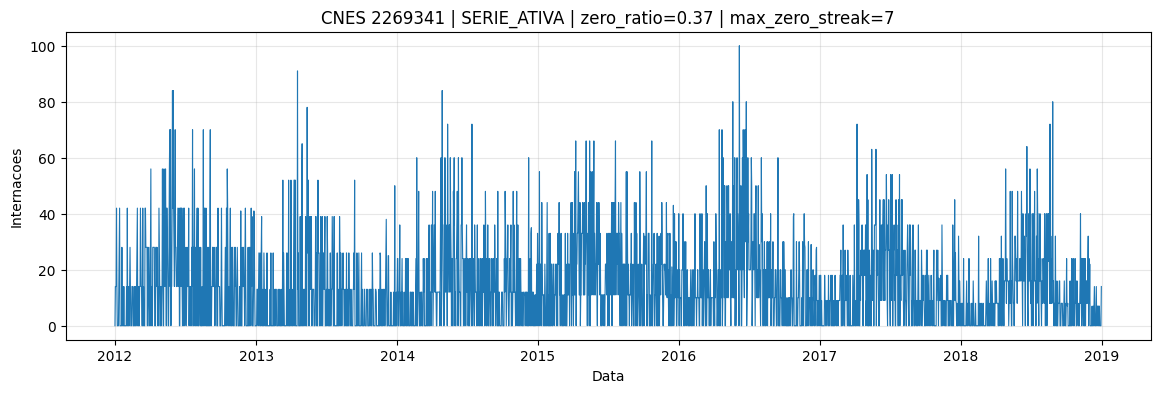

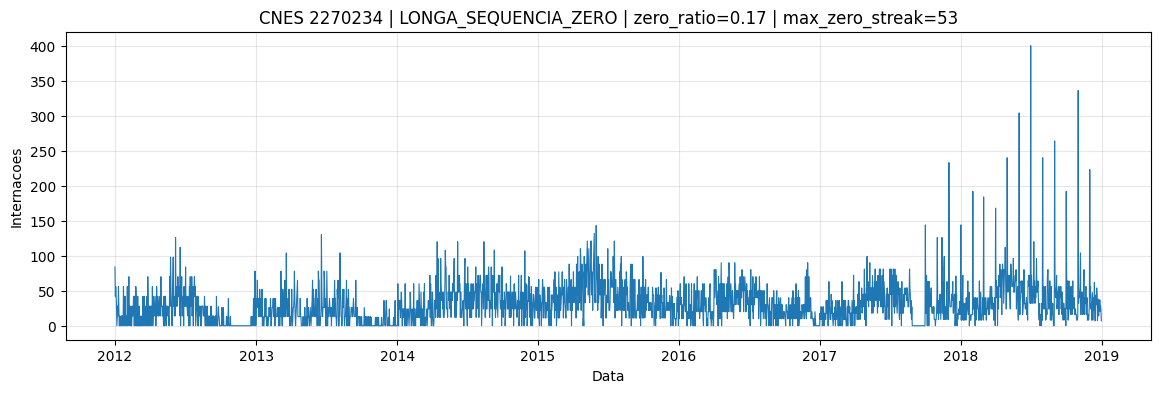

In [14]:
def plot_hospital(cnes: str, df_origem: pd.DataFrame, metricas_df: pd.DataFrame) -> None:
    cnes = str(cnes)
    d = df_origem[df_origem["CNES"].astype(str) == cnes].copy()
    if d.empty:
        print(f"CNES {cnes} nao encontrado.")
        return

    d = d.sort_values("data_dia")
    d["data_dia"] = pd.to_datetime(d["data_dia"])

    m = metricas_df[metricas_df["CNES"].astype(str) == cnes]
    classe = m["classe_serie"].iloc[0] if not m.empty else "SEM_CLASSE"
    zero_ratio = m["zero_ratio"].iloc[0] if not m.empty else np.nan
    max_streak = m["max_zero_streak_days"].iloc[0] if not m.empty else np.nan

    plt.figure(figsize=(14, 4))
    plt.plot(d["data_dia"], d["num_internacoes"], lw=0.8)
    plt.title(
        f"CNES {cnes} | {classe} | zero_ratio={zero_ratio:.2f} | max_zero_streak={max_streak}"
    )
    plt.xlabel("Data")
    plt.ylabel("Internacoes")
    plt.grid(alpha=0.3)
    plt.show()

display(metricas_hospitais.groupby("classe_serie").head(1)[["CNES", "classe_serie"]])
for _, r in metricas_hospitais.groupby("classe_serie").head(1).iterrows():
    plot_hospital(r["CNES"], df_hospitais_classificado, metricas_hospitais)


In [15]:
print(df_hospitais_classificado[(df_hospitais_classificado['classe_serie'] == 'SERIE_ATIVA') | (df_hospitais_classificado['classe_serie'] == 'LONGA_SEQUENCIA_ZERO')]["CNES"].unique())

<ArrowStringArray>
['2296748', '2269384', '2295423', '2291266', '2798662', '2277751', '2296306',
 '2269341', '2270609', '2296616', '2273411', '2270234']
Length: 12, dtype: str
